In [284]:
# Imports

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
	precision_score,
	recall_score,
    brier_score_loss,
	confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [285]:
def compute_metrics(df, threshold=0.7):

    y = df.y_true.values
    p = df.p_pred.values

    y_pred = (p > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y, p),
        "roc": roc_curve(y, p),

        "pr_auc": average_precision_score(y, p),
        "pr": precision_recall_curve(y, p),
        
        "f1": f1_score(y, y_pred),
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "brier": brier_score_loss(y, p),
        "confusion": {
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        },
        "n": len(df)
    }

In [286]:
def confusion_matrix_dataframe(cm):

    return pd.DataFrame(
        [
            [cm["TN"], cm["FP"]],
            [cm["FN"], cm["TP"]],
        ],
        index=["Actual Negative", "Actual Positive"],
        columns=["Predicted Negative", "Predicted Positive"]
    )

In [ ]:
def metrics_for(experiment_id=None):
	if experiment_id:
		filename = f"results.{experiment_id}"
	else:
		filename = "results"

	results = json.load(open(f"./data/{filename}.json"))
	df = pd.DataFrame(results)

	metrics = {}

	metrics["overall"] = compute_metrics(df)

	for doc_type in df.doc_type.unique():
		metrics[doc_type] = compute_metrics(df[df.doc_type == doc_type])

	return metrics, df

In [288]:
# Load metrics

#experiment_id = "baseline_sentence_nli_r1"
#experiment_id = "baseline_sentence_nli_r2"
experiment_id = "cluster_sentence_nli_r1"
metrics, df = metrics_for(experiment_id)

In [289]:
output_folder = f"data/{experiment_id}/"
if not os.path.isdir(output_folder):
	os.makedirs(output_folder)

In [290]:
# Results overview table

table = pd.DataFrame(metrics).T

table.drop(columns=['confusion', 'roc', 'pr'], inplace=True)

table = table.astype({ 'n': int })

latex = table.to_latex(
    float_format="%.3f",
    caption="Contradiction detection performance",
    label="tab:results",

)

with open(f"{output_folder}/results.tex", "w") as f:
    f.write(latex)

print(latex)

table

\begin{table}
\caption{Contradiction detection performance}
\label{tab:results}
\begin{tabular}{llllllllr}
\toprule
 & roc_auc & pr_auc & f1 & accuracy & precision & recall & brier & n \\
\midrule
overall & 0.664 & 0.672 & 0.661 & 0.616 & 0.599 & 0.739 & 0.325 & 664 \\
wiki & 0.712 & 0.742 & 0.708 & 0.651 & 0.636 & 0.797 & 0.310 & 232 \\
news & 0.671 & 0.684 & 0.590 & 0.618 & 0.633 & 0.554 & 0.280 & 225 \\
story & 0.617 & 0.616 & 0.669 & 0.575 & 0.543 & 0.873 & 0.391 & 207 \\
\bottomrule
\end{tabular}
\end{table}



,roc_auc,pr_auc,f1,accuracy,precision,recall,brier,n
overall,0.664257,0.671901,0.661355,0.615964,0.598558,0.738872,0.325024,664
wiki,0.711643,0.74245,0.707581,0.650862,0.636364,0.796748,0.309972,232
news,0.671184,0.683509,0.590476,0.617778,0.632653,0.553571,0.280302,225
story,0.61746,0.616442,0.669173,0.574879,0.542683,0.872549,0.390505,207


In [291]:
# Confusion matrix table per doc type

for doc_type in metrics.keys():
    cm_df = confusion_matrix_dataframe(metrics[doc_type]['confusion'])
    latex = cm_df.to_latex(
        caption=f"Confusion matrix for contradiction detection ({doc_type})",
        label="tab:confusion_matrix"
    )

    with open(f"{output_folder}/cm_{doc_type}.tex", "w") as f:
        f.write(latex)

    print(latex)
    print()

\begin{table}
\caption{Confusion matrix for contradiction detection (overall)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 160 & 167 \\
Actual Positive & 88 & 249 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (wiki)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 53 & 56 \\
Actual Positive & 25 & 98 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (news)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\toprule
 & Predicted Negative & Predicted Positive \\
\midrule
Actual Negative & 77 & 36 \\
Actual Positive & 50 & 62 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Confusion matrix for contradiction detection (story)}
\label{tab:confusion_matrix}
\begin{tabular}{lrr}
\to

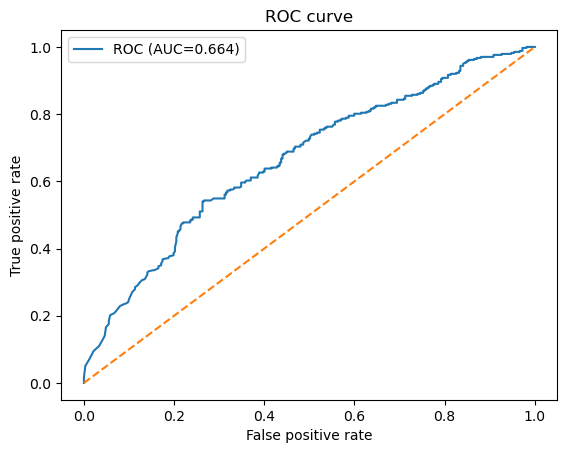

In [292]:
# ROC curve

fpr, tpr, _ = metrics["overall"]["roc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={metrics['overall']['roc_auc']:.3})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()

plt.savefig(f"{output_folder}/roc.jpg")

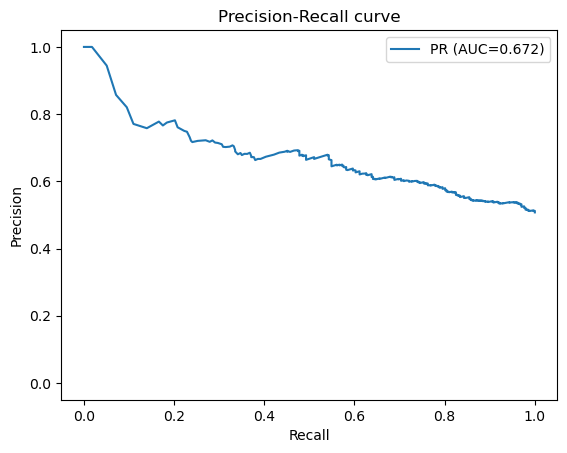

In [293]:
# Precision-Recall curve

prec, rec, _ = metrics['overall']['pr']

plt.figure()
plt.plot(rec, prec, label=f"PR (AUC={metrics['overall']['pr_auc']:.3})")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()

plt.savefig(f"{output_folder}/pr.jpg")

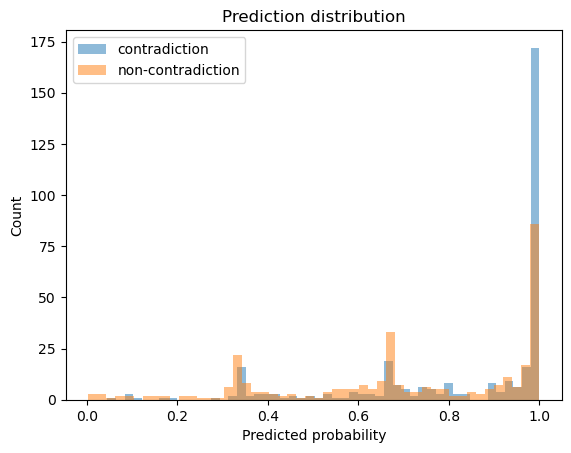

In [294]:
# Prediction distribution histogram

plt.figure()

plt.hist(df[df.y_true==1].p_pred, bins=50, alpha=0.5, label="contradiction")
plt.hist(df[df.y_true==0].p_pred, bins=50, alpha=0.5, label="non-contradiction")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Prediction distribution")
plt.legend()

plt.savefig(f"{output_folder}/histogram.jpg")

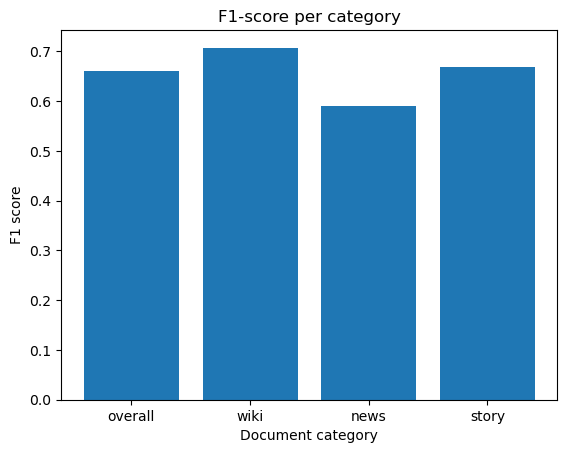

In [295]:
# F1 per category graph

cats = list(metrics.keys())
f1_scores = [metrics[c]["f1"] for c in cats]

plt.figure()
plt.bar(cats, f1_scores)
plt.ylabel("F1 score")
plt.xlabel("Document category")
plt.title("F1-score per category")

plt.savefig(f"{output_folder}/categories.jpg")